# Notebook 03 — Calibrating the Lens (Telling the Detector How It's Set)
## The hyperbolic embedding · Paper §4

---
### Story so far → where we are now

- **NB 01:** built the lens (the warp maths).
- **NB 02:** mounted it — we can now magnify any image.
- **NB 03 (here):** there's a problem we have to fix before the detector can work.

### The problem, with an analogy

Imagine handing someone a photo that has been magnified by an unknown amount in an unknown
corner, and asking them to point out where things *really* are. Without knowing the
magnification settings, they can't translate what they see back to reality.

Our detector faces exactly this. It will look at the **warped** image and try to place
bounding boxes. But the warp settings $(o, R)$ change from image to image (the lens aims at
different spots). If the detector doesn't *know* the current settings, it's guessing blind.

### The fix

We give the detector the lens settings as an extra input. We take the four warp numbers
$[o_x, o_y, R_x, R_y]$, pass them through a tiny network (the **HyperbolicEmbedding**) that
turns them into a 256-number "context vector", and **add that vector to every one of the
detector's internal queries**. It's like writing the current magnification setting on a
sticky note attached to every part of the detector's brain.

This is the same trick as *positional encoding* in Transformers (the technology behind
ChatGPT): inject information the model can't otherwise figure out from the raw input alone.

> **Why a whole notebook for this?** Because — as we prove in §6 — without this embedding the
> part of the network that aims the lens (the FoveationEstimator from NB 01) would receive
> **no training signal at all** and could never learn. This small component is what makes the
> "learnable" in "learnable foveation" actually work.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA   # pip install scikit-learn

torch.set_default_dtype(torch.float32)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | device: {DEVICE}')

PyTorch 2.12.0+cu130 | device: cpu


In [3]:
from telescope.geometry import hyperbolic_inverse, hyperbolic_foveated_transform
from telescope.warp import FoveationWarpLayer
from telescope.estimator import FoveationEstimator
from telescope.embedding import HyperbolicEmbedding, augment_queries

print('telescope package imported.')

telescope package imported.


---
## 1 · The `HyperbolicEmbedding` module

A 3-layer MLP that maps $[o_x, o_y, R_x, R_y] \in \mathbb{R}^4 \to \mathbb{R}^{256}$.

```
★ Insight ─────────────────────────────────────
  • The input is ONLY the 4 warp parameters, not the image features.
    This keeps the embedding lightweight and separable from the backbone.
  • The MLP must map a continuous 4-D space onto a 256-D one. Two hidden
    layers of 256 units give enough capacity for the detector to learn
    non-linear relationships between (o, R) and box geometry.
  • There is no activation on the final layer — the output can be
    positive or negative, just like the queries it is added to.
─────────────────────────────────────────────────
```

In [4]:
# Module comes from telescope.embedding — inspect its structure
emb = HyperbolicEmbedding(param_dim=4, query_dim=256)
print(emb)
n_params = sum(p.numel() for p in emb.parameters())
print(f'\nParameter count: {n_params:,}   (very small — intentional)')

# Shape check
params = torch.tensor([[0.0, 0.0, 0.6, 0.6],   # batch item 1: centred warp
                        [0.3, -0.2, 0.4, 0.5]])  # batch item 2: off-centre warp
out = emb(params)
print(f'\nInput  shape: {params.shape}   (B, 4)')
print(f'Output shape: {out.shape}       (B, query_dim)')

HyperbolicEmbedding(
  (mlp): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
  )
)

Parameter count: 132,864   (very small — intentional)

Input  shape: torch.Size([2, 4])   (B, 4)
Output shape: torch.Size([2, 256])       (B, query_dim)


---
## 2 · Augmenting the DETR object queries

In Deformable DETR, the decoder starts with a set of **object queries** — learned
vectors, one per candidate detection. There are typically 300 of them (for a
300-query DETR), each of dimension 256.

We broadcast-add the hyperbolic embedding across all queries:

```python
augmented = queries + embedding.unsqueeze(1)   # (B, 300, 256)
```

This is the `augment_queries` helper from `telescope.embedding`.

In [5]:
torch.manual_seed(0)
B, num_queries, query_dim = 2, 300, 256

# Simulate the DETR learned object queries (these are normally nn.Embedding weights)
queries = torch.randn(B, num_queries, query_dim)

# Predict embedding from foveation params
fov_params = torch.tensor([[0.0, 0.0, 0.6, 0.6],
                            [0.2, -0.1, 0.4, 0.5]])
embedding  = emb(fov_params)                        # (B, 256)

# Augment
aug_queries = augment_queries(queries, embedding)   # (B, 300, 256)

print(f'Original queries shape  : {queries.shape}')
print(f'Embedding shape         : {embedding.shape}')
print(f'Augmented queries shape : {aug_queries.shape}')

# Verify: augmented = original + embedding broadcast over queries
expected = queries + embedding.unsqueeze(1)
assert torch.allclose(aug_queries, expected)
print('\nPASS  augment_queries is correct broadcast addition')

# Show the shift magnitude relative to query norm
shift_norm = embedding.norm(dim=-1).mean().item()
query_norm = queries.norm(dim=-1).mean().item()
print(f'\nMean query norm     : {query_norm:.3f}')
print(f'Mean embedding norm : {shift_norm:.3f}')
print(f'Relative shift      : {shift_norm / query_norm:.1%}')
print('(After training, these norms will be calibrated by the loss)')

Original queries shape  : torch.Size([2, 300, 256])
Embedding shape         : torch.Size([2, 256])
Augmented queries shape : torch.Size([2, 300, 256])

PASS  augment_queries is correct broadcast addition

Mean query norm     : 15.990
Mean embedding norm : 1.208
Relative shift      : 7.6%
(After training, these norms will be calibrated by the loss)


---
## 3 · Tests

In [6]:
def test_output_shape():
    emb_t = HyperbolicEmbedding(param_dim=4, query_dim=256)
    x = torch.randn(8, 4)
    y = emb_t(x)
    assert y.shape == (8, 256), f'Wrong shape: {y.shape}'
    print('PASS  test_output_shape')


def test_gradient_flows_to_params():
    """Loss gradients must reach the 4 foveation parameters."""
    emb_t  = HyperbolicEmbedding()
    params = torch.randn(3, 4, requires_grad=True)
    loss   = emb_t(params).sum()
    loss.backward()
    assert params.grad is not None
    assert params.grad.abs().max() > 0
    print('PASS  test_gradient_flows_to_params')


def test_different_params_different_embeddings():
    """Two different foveation configs must produce different embeddings."""
    emb_t  = HyperbolicEmbedding()
    p1 = torch.tensor([[0.0,  0.0, 0.6, 0.6]])
    p2 = torch.tensor([[0.3, -0.2, 0.4, 0.5]])
    e1, e2 = emb_t(p1), emb_t(p2)
    assert not torch.allclose(e1, e2), 'Embedding is constant — MLP not working'
    print(f'PASS  test_different_params_different_embeddings  '
          f'(L2 dist={torch.dist(e1, e2):.3f})')


def test_gradcheck():
    """Verify analytic gradients match finite-difference approximation."""
    emb_t  = HyperbolicEmbedding(param_dim=4, query_dim=16, hidden=16)  # small for speed
    params = torch.randn(3, 4, dtype=torch.float64, requires_grad=True)
    # Cast model weights to float64 for gradcheck numerical precision
    emb_t  = emb_t.double()
    ok = torch.autograd.gradcheck(emb_t, (params,), eps=1e-6, atol=1e-4)
    assert ok
    print('PASS  test_gradcheck')


def test_augmented_query_gradients():
    """Gradients must flow from the detection loss back through
    augmented queries into the HyperbolicEmbedding parameters."""
    emb_t   = HyperbolicEmbedding()
    queries = torch.randn(2, 10, 256)
    params  = torch.tensor([[0.1, -0.1, 0.5, 0.5],
                             [0.0,  0.2, 0.6, 0.4]])
    aug = augment_queries(queries, emb_t(params))
    aug.sum().backward()
    for name, p in emb_t.named_parameters():
        assert p.grad is not None, f'No grad for {name}'
    print('PASS  test_augmented_query_gradients')


print('Running embedding tests...\n')
test_output_shape()
test_gradient_flows_to_params()
test_different_params_different_embeddings()
test_gradcheck()
test_augmented_query_gradients()
print('\nAll embedding tests passed.')

Running embedding tests...

PASS  test_output_shape
PASS  test_gradient_flows_to_params
PASS  test_different_params_different_embeddings  (L2 dist=0.290)
PASS  test_gradcheck
PASS  test_augmented_query_gradients

All embedding tests passed.


---
## 4 · Peeking inside the embedding — how to read the PCA plots

The embedding turns 4 input numbers into a 256-number vector. We can't draw 256 dimensions,
so we use **PCA** (Principal Component Analysis) — a standard technique that squashes
high-dimensional data down to 2 dimensions for plotting, keeping as much of the variation as
possible. Think of it as casting a shadow of a complex shape onto a wall so you can see its
overall form.

Each dot below is one warp setting, coloured by one of its parameters:

- **Left panel:** we sweep the lens centre $o_x$ left-to-right (colour) and plot where each
  lands in embedding-space.
- **Right panel:** we sweep the radius $R$ (colour).

**What to look for:** a **smooth colour gradient** — dots of similar colour sitting near each
other. That tells us similar warp settings produce similar context vectors, which is exactly
what we want: the embedding is a *continuous, organised* translation of the settings, not
random noise. If the colours were scattered randomly, the embedding would be useless and the
detector couldn't rely on it.

(These plots use an untrained network, so they show the embedding's *inherent* smoothness
from its structure. After training, the same plot would additionally reflect what the
detector found useful.)

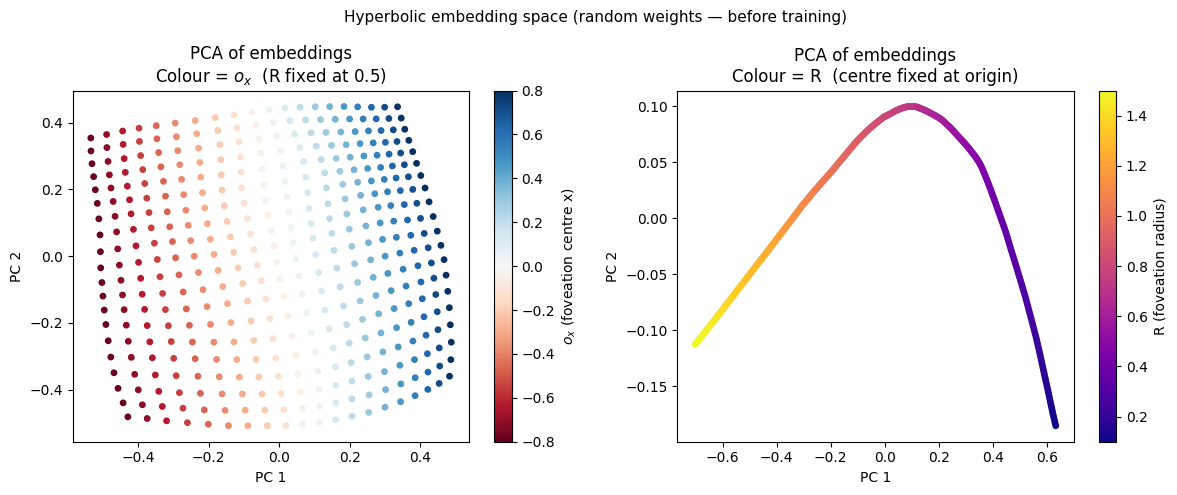

Smooth colour gradients = nearby parameters → nearby embeddings (continuity).
After training the structure will reflect the detection geometry.


In [7]:
torch.manual_seed(42)
emb_viz = HyperbolicEmbedding()
emb_viz.eval()

# ── Sweep 1: vary foveation centre (o_x, o_y), fix R ─────────────────────────
N = 20
ox_vals = torch.linspace(-0.8, 0.8, N)
oy_vals = torch.linspace(-0.8, 0.8, N)
grid_ox, grid_oy = torch.meshgrid(ox_vals, oy_vals, indexing='ij')
Rx = torch.full_like(grid_ox, 0.5)
Ry = torch.full_like(grid_ox, 0.5)

params_centre = torch.stack([
    grid_ox.flatten(), grid_oy.flatten(), Rx.flatten(), Ry.flatten()
], dim=-1)   # (N², 4)

with torch.no_grad():
    embs_centre = emb_viz(params_centre).numpy()   # (N², 256)

pca_c = PCA(n_components=2).fit_transform(embs_centre)   # (N², 2)

# ── Sweep 2: vary radius R, fix centre ───────────────────────────────────────
R_vals  = torch.linspace(0.1, 1.5, N * N)
params_R = torch.stack([
    torch.zeros(N*N), torch.zeros(N*N), R_vals, R_vals
], dim=-1)   # (N², 4)

with torch.no_grad():
    embs_R = emb_viz(params_R).numpy()

pca_r = PCA(n_components=2).fit_transform(embs_R)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc0 = axes[0].scatter(pca_c[:, 0], pca_c[:, 1],
                       c=grid_ox.flatten().numpy(), cmap='RdBu', s=15)
plt.colorbar(sc0, ax=axes[0], label='$o_x$ (foveation centre x)')
axes[0].set_title('PCA of embeddings\nColour = $o_x$  (R fixed at 0.5)')
axes[0].set_xlabel('PC 1'); axes[0].set_ylabel('PC 2')

sc1 = axes[1].scatter(pca_r[:, 0], pca_r[:, 1],
                       c=R_vals.numpy(), cmap='plasma', s=15)
plt.colorbar(sc1, ax=axes[1], label='R (foveation radius)')
axes[1].set_title('PCA of embeddings\nColour = R  (centre fixed at origin)')
axes[1].set_xlabel('PC 1'); axes[1].set_ylabel('PC 2')

plt.suptitle('Hyperbolic embedding space (random weights — before training)',
              fontsize=11)
plt.tight_layout()
plt.show()

print('Smooth colour gradients = nearby parameters → nearby embeddings (continuity).')
print('After training the structure will reflect the detection geometry.')

---
## 5 · Which setting matters most? — how to read the sensitivity bars

Here we nudge each of the four warp parameters by a tiny amount and measure how much the
output context vector moves in response. The bar chart shows one bar per parameter; **taller
bar = the embedding is more sensitive to that parameter.**

**How to read it:** a tall bar for, say, $o_x$ means "shifting the lens left/right strongly
changes the message sent to the detector" — the detector pays a lot of attention to that
setting. A short bar means that parameter barely affects the context vector.

This is a debugging tool more than a result. With an untrained network the bar heights come
from the random initial weights, so the exact values aren't meaningful yet. After training,
this same chart tells you whether the model actually *uses* all four knobs or has learned to
ignore some — a quick health check on whether the calibration mechanism is pulling its weight.

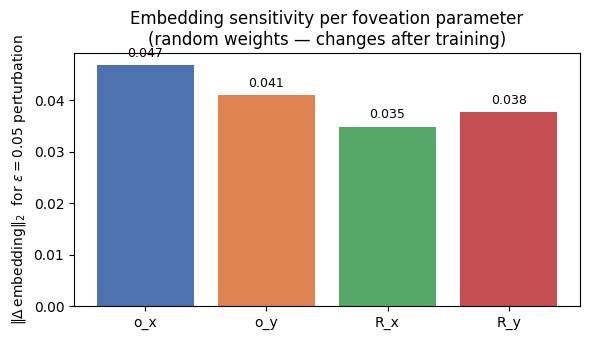

In [8]:
torch.manual_seed(0)
emb_s = HyperbolicEmbedding()
emb_s.eval()

# Reference point: centred foveation with R=0.5
ref = torch.tensor([[0.0, 0.0, 0.5, 0.5]])
param_names = ['o_x', 'o_y', 'R_x', 'R_y']
eps = 0.05

sensitivities = []
with torch.no_grad():
    e_ref = emb_s(ref)   # (1, 256)
    for i, name in enumerate(param_names):
        perturbed = ref.clone()
        perturbed[0, i] += eps
        e_pert = emb_s(perturbed)
        delta  = torch.dist(e_ref, e_pert).item()
        sensitivities.append(delta)

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(param_names, sensitivities, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
ax.set_ylabel(f'$\\|\\Delta\\,\\text{{embedding}}\\|_2$  for $\\epsilon={eps}$ perturbation')
ax.set_title('Embedding sensitivity per foveation parameter\n(random weights — changes after training)')
for bar, val in zip(bars, sensitivities):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6 · Full Stage 1 pipeline — and why `HyperbolicEmbedding` is not optional

A key architectural insight that this cell makes explicit:

> **`FoveationEstimator` receives zero gradient from the warp alone.**
>
> `HyperbolicInverseNR.backward` returns `None` for `o` and `R` — intentionally,
> because implementing their gradients would require differentiating through the
> NR iteration w.r.t. the transform parameters, not just w.r.t. the input points.
>
> The ONLY gradient path back to `FoveationEstimator` is through `HyperbolicEmbedding`:
> `loss → aug_queries → embedding → fov_params → (o, R) → fov_estimator`.

This is why the paper trains *another* FFN for the embedding — it is the mechanism
that lets the foveation estimator be supervised end-to-end by the detection loss.

In [9]:
class Stage1FoveationPipeline(nn.Module):
    """Stage 1 of Telescope: estimate warp params, warp image, produce hyperbolic embedding.

    The FoveationEstimator receives gradients through TWO paths:
        Path A (warp) :  loss → warped_image → grid_sample → source_grid
                         BUT: HyperbolicInverseNR.backward returns None for o,R
                         → NO gradient reaches fov_estimator this way.

        Path B (embed):  loss → aug_queries → HyperbolicEmbedding → fov_params → o,R
                         → gradient DOES reach fov_estimator this way.

    This is why HyperbolicEmbedding is architecturally necessary, not optional.
    Without it, the FoveationEstimator would receive zero gradient from the
    detection loss and would never learn where to foveate.
    """

    def __init__(self, enc_out_dim: int = 64, num_queries: int = 10,
                 query_dim: int = 64) -> None:
        super().__init__()
        self.encoder_stub = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(3, enc_out_dim),
        )
        self.fov_estimator   = FoveationEstimator(enc_out_dim, hidden=enc_out_dim)
        self.warp_layer      = FoveationWarpLayer(alpha=2.0, p=2.0)
        self.hyperbolic_emb  = HyperbolicEmbedding(param_dim=4, query_dim=query_dim)
        self.object_queries  = nn.Embedding(num_queries, query_dim)

    def forward(self, image: Tensor):
        B = image.shape[0]

        # Stage 1a: estimate foveation params
        small = F.interpolate(image, (64, 64), mode='bilinear', align_corners=True)
        feats = self.encoder_stub(small)
        o, R  = self.fov_estimator(feats)

        # Stage 1b: warp image
        warped = self.warp_layer(image, o, R)

        # Stage 1c: embed params → augment queries
        fov_params  = torch.cat([o, R.unsqueeze(-1).expand(-1, 2)], dim=-1)  # (B, 4)
        embedding   = self.hyperbolic_emb(fov_params)                         # (B, D)
        queries     = self.object_queries.weight.unsqueeze(0).expand(B, -1, -1)
        aug_queries = augment_queries(queries, embedding)                      # (B, Q, D)

        return warped, aug_queries, o, R


# ── Forward pass ─────────────────────────────────────────────────────────────
torch.manual_seed(0)
pipeline = Stage1FoveationPipeline(enc_out_dim=64, num_queries=10, query_dim=64)
dummy    = torch.rand(2, 3, 128, 128)

warped_out, aug_q, o_out, R_out = pipeline(dummy)

print('Stage 1 output shapes:')
print(f'  warped_image  : {warped_out.shape}')
print(f'  aug_queries   : {aug_q.shape}')
print(f'  o (centres)   : {o_out.shape}')
print(f'  R (radii)     : {R_out.shape}')

# ── Gradient flow check ───────────────────────────────────────────────────────
# The detection loss touches both outputs.
# aug_q.sum() is the path that carries grads back to fov_estimator.
loss = aug_q.sum() + warped_out.mean()
loss.backward()

print('\nGradient flow audit:')
for module_name, module in [('fov_estimator',  pipeline.fov_estimator),
                              ('hyperbolic_emb', pipeline.hyperbolic_emb)]:
    for name, param in module.named_parameters():
        has_grad = param.grad is not None and param.grad.abs().max().item() > 0
        assert has_grad, (
            f'No grad for {module_name}.{name} — '
            f'check that aug_q is included in the loss'
        )
    print(f'  {module_name:<20}  all grads OK')

print('\nFoveationEstimator is trainable via the hyperbolic embedding path.')

Stage 1 output shapes:
  warped_image  : torch.Size([2, 3, 128, 128])
  aug_queries   : torch.Size([2, 10, 64])
  o (centres)   : torch.Size([2, 2])
  R (radii)     : torch.Size([2])

Gradient flow audit:
  fov_estimator         all grads OK
  hyperbolic_emb        all grads OK

FoveationEstimator is trainable via the hyperbolic embedding path.


---
## Summary

| Component | Input | Output | Purpose |
|---|---|---|---|
| `FoveationEstimator` | encoder features `(B, D)` | `o (B,2)`, `R (B,)` | Predict where/how to warp |
| `FoveationWarpLayer` | image `(B,C,H,W)` + `o`, `R` | warped image | Apply Φ to pixels |
| `HyperbolicEmbedding` | params `(B, 4)` | embedding `(B, 256)` | Tell the detector about the warp |
| `augment_queries` | queries + embedding | augmented queries | Inject context into DETR |

**Next**: Notebook 04 will implement the **Deformable DETR detection head** that
consumes these augmented queries and the warped image features to predict
Riemannian bounding boxes $b' = [\Phi(c), \|t_x\|, \|t_y\|]$.